In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd '/content/drive/MyDrive/Colab Notebooks/Projekti/Facial Emotion Recognition'

/content/drive/MyDrive/Colab Notebooks/Projekti/Facial Emotion Recognition


In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.head())
print("\n\n")
print("Broj slika: ", len(df))

   emotion                                             pixels
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        0  151 150 147 155 148 133 111 140 170 174 182 15...
2        2  231 212 156 164 174 138 161 173 182 200 106 38...
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Broj slika:  28709


In [ ]:
print("Broj duplih slika: ", df.duplicated(subset=['pixels']).sum())

df = df.drop_duplicates(subset=['pixels'])

print("Broj slika nakon ciscenja: ", len(df))




Broj duplih slika:  1236
Broj slika nakon ciscenja:  27473


In [ ]:
import numpy as np

#pretvaranje pikseliziranih slika u format za neuronske mreže
def process_pixels(df):
    X = []
    for pixel_sequence in df['pixels']:
        X.append(np.array(pixel_sequence.split(), dtype='float32').reshape(48,48,1))
    X = np.array(X)
    X /= 255.0  # normalizacija
    return X

X_train = process_pixels(df)


In [ ]:
print(X_train.shape)

(27473, 48, 48, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical

#One-hot kodiranje
#pretvara klase u vektor [1,0,0,0,0,0,0]
y_train = to_categorical(df['emotion'], num_classes=7)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization

#model = Sequential([
    #Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    #MaxPooling2D(2,2),
    #Conv2D(64, (3,3), activation='relu'),
    #MaxPooling2D(2,2),
    #Flatten(),
    #Dense(128, activation='relu'),
    #Dropout(0.5),
    #Dense(7, activation='softmax')
#])


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(X_train_final.shape, X_val.shape)


(21978, 48, 48, 1) (5495, 48, 48, 1)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [ ]:
history = model.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=50
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.2131 - loss: 2.5492 - val_accuracy: 0.2841 - val_loss: 1.7654
Epoch 2/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.2571 - loss: 1.8098 - val_accuracy: 0.2963 - val_loss: 1.7163
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.2674 - loss: 1.7809 - val_accuracy: 0.2732 - val_loss: 1.7238
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.2668 - loss: 1.7609 - val_accuracy: 0.2894 - val_loss: 1.6774
Epoch 5/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.2755 - loss: 1.7348 - val_accuracy: 0.3254 - val_loss: 1.6065
Epoch 6/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.2792 - loss: 1.6937 - val_accuracy: 0.4007 - val_loss: 1.5562
Epoch 7/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.3050 - loss: 1.6620 - val_accuracy: 0.3956 - val_loss: 1.5897
Epoch 8/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3264 - loss: 1.6434 - val_accurac

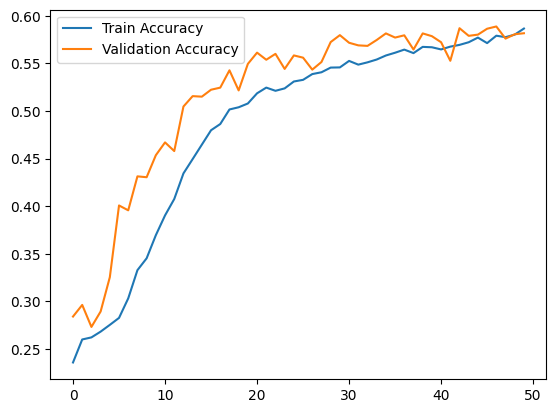

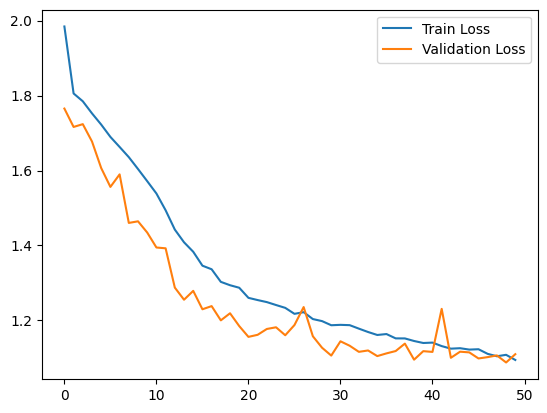

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


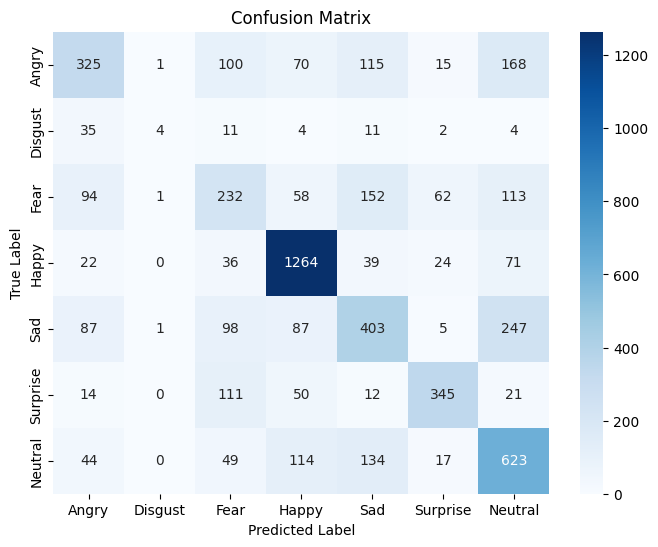

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Convert one-hot encoded y_val to class labels
true_labels = np.argmax(y_val, axis=1)

# Get predicted labels (already computed in previous steps)
predicted_labels = np.argmax(model.predict(X_val), axis=1) # This was already done in cell XyvoJ3NIvh6_

# Define emotion labels (assuming standard FER2013 dataset labels)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Analiza matrice konfuzije:

✔️ Happy — vrlo dobro pogođen

1264 točnih → model jako dobro hvata osmijeh
→ jer je to najprepoznatljiviji i najrazlikovniji izraz.

✔️ Surprise — dobro pogođen

403 točnih → Surprise također ima jako izražen obrazac (podignute obrve, širom otvorene oči).

❗ Neutral / Sad / Fear / Angry — međusobno se MIJEŠAJU

Iako Neutral nije najbrojnija klasa, model ga često predviđa jer izraz neutralnog lica ima vrlo malo jakih vizualnih značajki.

Kada model nije siguran, predikcije često idu u klase s niskom aktivacijom mišića — najčešće Neutral ili Sad.

Suprotno tome, Happy ima vrlo karakterističnu vizualnu strukturu osmijeha, pa ga model detektira najtočnije.

In [ ]:
from sklearn.metrics import classification_report

y_true = np.argmax(y_val, axis=1)
y_pred = np.argmax(model.predict(X_val), axis=1)

print(classification_report(y_true, y_pred, target_names=[
    "Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"
]))


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

       Angry       0.52      0.41      0.46       794
     Disgust       0.57      0.06      0.10        71
        Fear       0.36      0.33      0.34       712
       Happy       0.77      0.87      0.81      1456
         Sad       0.47      0.43      0.45       928
    Surprise       0.73      0.62      0.67       553
     Neutral       0.50      0.64      0.56       981

    accuracy                           0.58      5495
   macro avg       0.56      0.48      0.49      5495
weighted avg       0.58      0.58      0.57      5495



In [ ]:
from sklearn.metrics import roc_auc_score

y_val_onehot = y_val  # već je one-hot
y_pred_probs = model.predict(X_val)

auc = roc_auc_score(y_val_onehot, y_pred_probs, multi_class='ovr')
print("ROC AUC:", auc)


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ROC AUC: 0.8724354668376194


In [ ]:
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

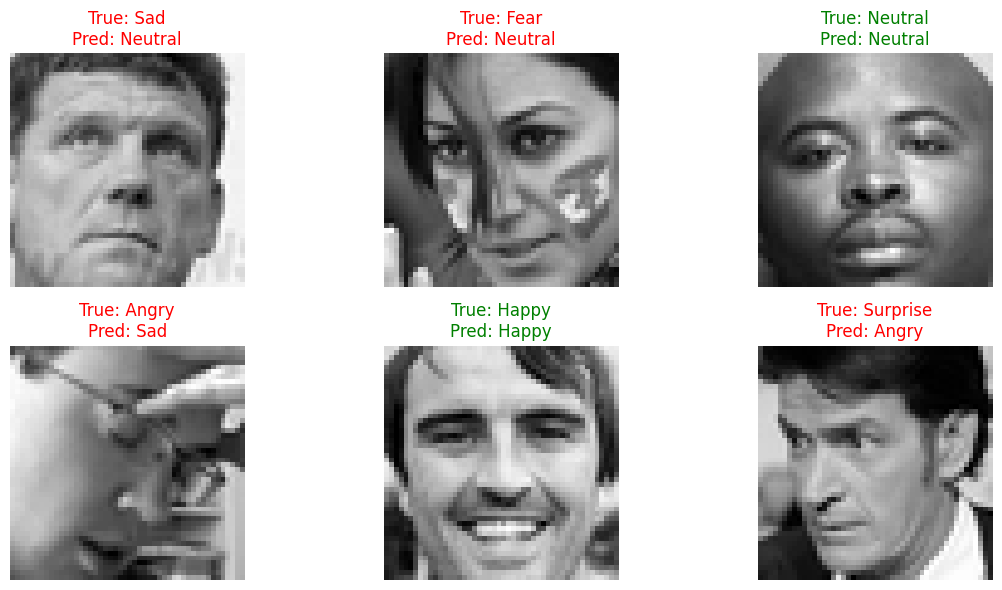

In [ ]:
import random
import matplotlib.pyplot as plt

indices = random.sample(range(len(X_val)), 6)

plt.figure(figsize=(12,6))
for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)

    plt.imshow(X_val[idx].reshape(48,48), cmap='gray')
    plt.axis('off')

    true = emotion_labels[y_true[idx]]
    pred = emotion_labels[y_pred[idx]]

    color = "green" if y_true[idx] == y_pred[idx] else "red"

    plt.title(f"True: {true}\nPred: {pred}", color=color)

plt.tight_layout()
plt.show()

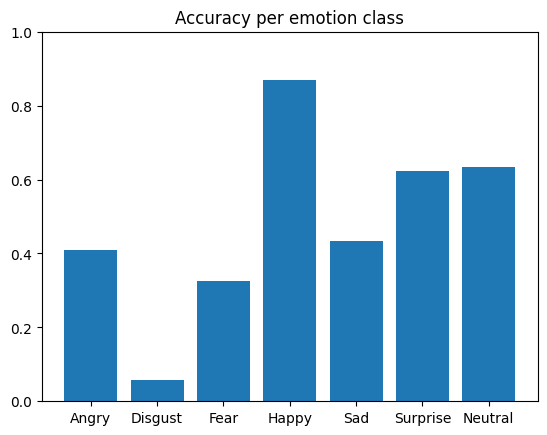

In [ ]:
import numpy as np

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.bar(range(7), per_class_accuracy)
plt.xticks(range(7), ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"])
plt.ylim(0,1)
plt.title("Accuracy per emotion class")
plt.show()
